In [1]:
import numpy as np 
import pandas as pd
import torch
import open_clip
import os
from urllib.request import urlopen
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

/home/ashley-bravo/.conda/envs/sigma/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

#Ponemos la ruta al dataset desde kaggle
base_path = "/home/ashley-bravo/r-train/roco/all_data/"
train_path = os.path.join(base_path, "train")
img_path = os.path.join(train_path, "radiology", "images")
csv_path = os.path.join(base_path, "Trainingdataset.csv")

df = pd.read_csv(csv_path)

df["image_path"] = df["name"].apply(lambda x: f"{img_path}/{x}")
print(df.head())

val_base_path = "/home/ashley-bravo/r-train/roco/all_data/"
val_path = os.path.join(val_base_path, "validation")
val_img = os.path.join(val_path, "radiology", "images")
val_csv = os.path.join(val_path, "radiology", "valdata.csv")

df_val = pd.read_csv(val_csv)
df_val["image_path"] = df_val["name"].apply(lambda x: os.path.join(val_img, x))

# Filtrar existentes y válidas (igual que en train)
real_val   = set(os.listdir(val_img))
df_val     = df_val[df_val["name"].isin(real_val)].reset_index(drop=True)

valid_val  = []
for name in tqdm(df_val["name"], desc="Verificando val"):
    path = os.path.join(val_img, name)
    try:
        with Image.open(path) as img:
            img.verify()
        valid_val.append(name)
    except Exception:
        pass
    
df_val = df_val[df_val["name"].isin(set(valid_val))].reset_index(drop=True)
print(f"Número de imágenes para validación: {len(df_val)} ")




   Unnamed: 0          id                                    name  \
0           0  ROCO_00002          PMC4083729_AMHSR-4-14-g002.jpg   
1           1  ROCO_00003       PMC2837471_IJD2009-150251.001.jpg   
2           2  ROCO_00004  PMC2505281_11999_2007_30_Fig6_HTML.jpg   
3           3  ROCO_00005       PMC3745845_IJD2013-683423.005.jpg   
4           4  ROCO_00007   PMC4917066_amjcaserep-17-301-g001.jpg   

                                             caption  \
0   Computed tomography scan in axial view showin...   
1   Bacterial contamination occurred after comple...   
2   The patient had residual paralysis of the han...   
3    Panoramic radiograph after immediate loading.\n   
4   Plain abdomen x-ray: Multiple air levels at t...   

                                          image_path  exists  
0  /home/ashley-bravo/r-train/roco/all_data/train...    True  
1  /home/ashley-bravo/r-train/roco/all_data/train...    True  
2  /home/ashley-bravo/r-train/roco/all_data/train...    Tru

Verificando val:  10%|▉         | 804/8175 [00:00<00:01, 4035.36it/s]

Verificando val: 100%|██████████| 8175/8175 [00:02<00:00, 4084.15it/s]

Número de imágenes para validación: 8175 


In [5]:
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

model = model.to(device)


/home/ashley-bravo/.conda/envs/sigma/lib/python3.10/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [6]:
def extract_embeddings(model, val_loader, device):
    model.eval()
    all_image_features = []
    all_text_features  = []

    with torch.no_grad():
        for images, texts in tqdm(val_loader, desc="Extrayendo embeddings"):
            images = images.to(device)
            texts  = texts.to(device)

            img_feat, txt_feat, _ = model(images, texts)

            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

            all_image_features.append(img_feat.cpu())
            all_text_features.append(txt_feat.cpu())

    return torch.cat(all_image_features), torch.cat(all_text_features)

def recall_at_k(image_features, text_features, ks=(1, 5, 10)):
    """
    Para cada imagen, busca su caption correcto entre los K más similares.
    El ground truth es la diagonal (imagen i ↔ texto i).
    """
    # Matriz de similitud (N x N)
    sim_matrix = image_features @ text_features.T  # cosine sim (ya normalizados)

    results = {}
    N = sim_matrix.shape[0]

    for k in ks:
        # Image → Text: para cada imagen, top-K textos más similares
        topk_i2t = sim_matrix.topk(k, dim=1).indices        # (N, k)
        correct_i2t = (topk_i2t == torch.arange(N).unsqueeze(1)).any(dim=1)
        r_i2t = correct_i2t.float().mean().item() * 100

        # Text → Image: para cada texto, top-K imágenes más similares
        topk_t2i = sim_matrix.T.topk(k, dim=1).indices      # (N, k)
        correct_t2i = (topk_t2i == torch.arange(N).unsqueeze(1)).any(dim=1)
        r_t2i = correct_t2i.float().mean().item() * 100

        results[f"R@{k} I→T"] = round(r_i2t, 2)
        results[f"R@{k} T→I"] = round(r_t2i, 2)

    return results

def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, texts in loader:
            images = images.to(device)
            texts = texts.to(device)

            image_features, text_features, logit_scale = model(images, texts)

            logits_per_image = logit_scale * image_features @ text_features.T
            logits_per_text  = logits_per_image.T

            labels = torch.arange(len(images)).to(device)

            loss = (
                F.cross_entropy(logits_per_image, labels)
                + F.cross_entropy(logits_per_text, labels)
            ) / 2

            total_loss += loss.item()

    return total_loss / len(loader)

In [7]:
class TrainDataset(Dataset):
    def __init__(self, df, preprocess, tokenizer):
        self.df = df.reset_index(drop=True)
        self.preprocess = preprocess
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        image = self.preprocess(image)

        text = self.tokenizer(
            row["caption"],
            context_length=256
        )[0]

        return image, text
    
class ValDataset(Dataset):
    def __init__(self, df, preprocess, tokenizer):
        self.df         = df.reset_index(drop=True)
        self.preprocess = preprocess
        self.tokenizer  = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.preprocess(image)
        text  = self.tokenizer(row["caption"], context_length=256)[0]
        return image, text

In [8]:
train_dataset = TrainDataset(df, preprocess_train, tokenizer)
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,num_workers=2,pin_memory=True)

val_dataset_base = ValDataset(df_val, preprocess_val, tokenizer)
val_loader_ft  = DataLoader(val_dataset_base, batch_size=64,shuffle=False, num_workers=2, pin_memory=True)

In [9]:
for param in model.parameters():
    param.requires_grad = False

#Solo entrenamos cuatro  ultima capas
for param in model.visual.trunk.blocks[-4:].parameters():
    param.requires_grad = True

for param in model.visual.head.parameters():
    param.requires_grad = True

    
# Verificamos cuántos parámetros se entrenan
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:    {total:,}")
print(f"Parámetros entrenables: {trainable:,}  ({100*trainable/total:.1f}%)")

epochs = 5

param_groups = [
    {"params": model.visual.trunk.blocks[-4:-2].parameters(), "lr": 1e-7},
    {"params": model.visual.trunk.blocks[-2:].parameters(),   "lr": 3e-7},
    {"params": model.visual.head.parameters(),                "lr": 5e-7},
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=epochs,      # un ciclo completo en N épocas
    eta_min=1e-8       # nunca baja de esto
)

Parámetros totales:    195,902,721
Parámetros entrenables: 28,744,704  (14.7%)


In [10]:
print("Iniciaremos entrenamiento")

best_recall = 0
no_improve  = 0
patience    = 3
train_losses = []
val_losses = []
recall_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (images, texts) in enumerate(train_loader):
        images = images.to(device)
        texts  = texts.to(device)

        image_features, text_features, logit_scale = model(images, texts)

        logits_per_image = logit_scale * image_features @ text_features.T
        logits_per_text  = logits_per_image.T
        labels = torch.arange(len(images)).to(device)

        loss = (F.cross_entropy(logits_per_image, labels) +
                F.cross_entropy(logits_per_text,  labels)) / 2

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()),
            max_norm=1.0
        )
        optimizer.step()
        total_loss += loss.item()

    # scheduler paso por época (no por batch)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    val_loss = evaluate_loss(model, val_loader_ft, device)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f} | "
          f"Validation Loss: {val_loss:.4f} | "
          f"lr: {current_lr:.2e}")

    img_feat, txt_feat = extract_embeddings(model, val_loader_ft, device)
    metrics = recall_at_k(img_feat, txt_feat, ks=(1,))
    current_recall = metrics["R@1 I→T"]
    recall_history.append(current_recall)
    print(f"         R@1 I→T: {current_recall:.2f}%  (mejor: {best_recall:.2f}%)")

    if current_recall > best_recall:
        best_recall = current_recall
        no_improve  = 0
        torch.save(model.state_dict(), "biomedclip_best_now.pt")
        print(f"  Nuevo mejor guardado")
    else:
        no_improve += 1
        print(f"         Sin mejora ({no_improve}/{patience})")
        if no_improve >= patience:
            print(f"\nEarly stopping en época {epoch+1}")
            break

print(f"\nMejor R@1 I→T alcanzado: {best_recall:.2f}%")


Iniciaremos entrenamiento
Epoch 1/5 - Train Loss: 0.0934 | Validation Loss: 0.1790 | lr: 9.14e-08


Extrayendo embeddings: 100%|██████████| 128/128 [00:26<00:00,  4.76it/s]


         R@1 I→T: 33.61%  (mejor: 0.00%)
  Nuevo mejor guardado
Epoch 2/5 - Train Loss: 0.0933 | Validation Loss: 0.1778 | lr: 6.89e-08


Extrayendo embeddings: 100%|██████████| 128/128 [00:27<00:00,  4.68it/s]


         R@1 I→T: 33.76%  (mejor: 33.61%)
  Nuevo mejor guardado
Epoch 3/5 - Train Loss: 0.0921 | Validation Loss: 0.1772 | lr: 4.11e-08


...

         R@1 I→T: 33.86%  (mejor: 33.76%)
  Nuevo mejor guardado
Epoch 4/5 - Train Loss: 0.0920 | Validation Loss: 0.1770 | lr: 1.86e-08


Extrayendo embeddings: 100%|██████████| 128/128 [00:27<00:00,  4.67it/s]


         R@1 I→T: 33.92%  (mejor: 33.86%)
  Nuevo mejor guardado
Epoch 5/5 - Train Loss: 0.0941 | Validation Loss: 0.1770 | lr: 1.00e-08


Extrayendo embeddings: 100%|██████████| 128/128 [00:27<00:00,  4.71it/s]


         R@1 I→T: 34.01%  (mejor: 33.92%)
  Nuevo mejor guardado

Mejor R@1 I→T alcanzado: 34.01%


In [3]:
print(device)

cuda


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"


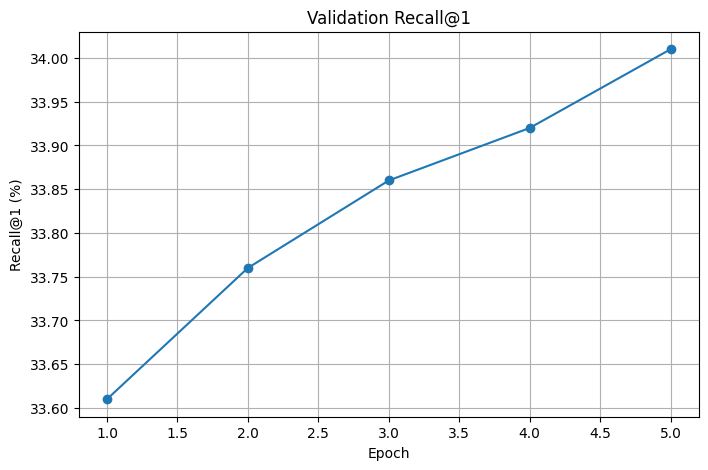

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(recall_history)+1),
    recall_history,
    marker="o"
)

plt.xlabel("Época")
plt.ylabel("Recall@1 (%)")
plt.title("Validation Recall@1")
plt.grid(True)


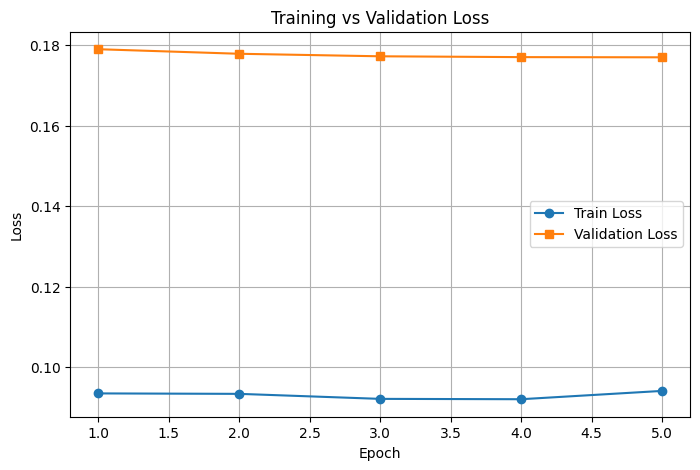

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_losses)+1),
    train_losses,
    marker="o",
    label="Train Loss"
)

plt.plot(
    range(1, len(val_losses)+1),
    val_losses,
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()




## Resultados en test set


### Primero vamos a evaluar en el modelo que acabamos de entrenar

In [18]:

test_path = os.path.join(base_path, "test")
test_img = os.path.join(test_path, "radiology", "images")
test_csv = os.path.join(test_path, "radiology", "testdata.csv")

df_test = pd.read_csv(test_csv)
df_test["image_path"] = df_test["name"].apply(lambda x: os.path.join(test_img, x))
real_test   = set(os.listdir(test_img))
df_test     = df_test[df_test["name"].isin(real_test)].reset_index(drop=True)
valid_test  = []
for name in tqdm(df_test["name"], desc="Verificando test"):
    path = os.path.join(test_img, name)
    try:
        with Image.open(path) as img:
            img.verify()
        valid_test.append(name)
    except Exception:
        pass
df_test = df_test[df_test["name"].isin(set(valid_test))].reset_index(drop=True)
print(f"Número de imágenes para test: {len(df_test)} ")

Verificando test: 100%|██████████| 8176/8176 [00:05<00:00, 1546.25it/s]

Número de imágenes para test: 8176 


In [26]:
test_dataset_base = ValDataset(df_test, preprocess_val, tokenizer)
val_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_base, _, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
model_base = model_base.to(device)

img_feat_base, txt_feat_base = extract_embeddings(model_base, val_loader_base, device)

metrics_base = recall_at_k(img_feat_base, txt_feat_base, ks=(1, 5, 10))

del model_base  
torch.cuda.empty_cache()

print("Cargando modelo fine-tuned...")
model_ft, _, preprocess_val_ft = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)


model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_best_now.pt", map_location=device))
model_ft = model_ft.to(device)

test_dataset_ft = ValDataset(df_test, preprocess_val_ft, tokenizer)
val_loader_ft  = DataLoader(test_dataset_ft, batch_size=64,
                             shuffle=False, num_workers=2, pin_memory=True)

img_feat_ft, txt_feat_ft = extract_embeddings(model_ft, val_loader_ft, device)
metrics_ft = recall_at_k(img_feat_ft, txt_feat_ft, ks=(1, 5, 10))

del model_ft
torch.cuda.empty_cache()


print("\n─────────────────────────────────────────────────────────")
print(f"{'Métrica':<15} {'BioMedCLIP':>10} {'Fine-tuned Model':>12} {'Δ':>8}")
print("─────────────────────────────────────────────────────────")

for key in metrics_base:
    base = metrics_base[key]
    ft   = metrics_ft[key]
    diff = ft - base
    arrow = "↑" if diff > 0 else "↓"
    print(f"{key:<15} {base:>9.2f}%  {ft:>10.2f}%  {arrow}{abs(diff):>5.2f}%")

print("─────────────────────────────────────────────────────────")


Extrayendo embeddings: 100%|██████████| 128/128 [00:25<00:00,  4.94it/s]


Cargando modelo fine-tuned...


/tmp/ipykernel_3384321/1854330810.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_best_now.pt


─────────────────────────────────────────────────────────
Métrica         BioMedCLIP Fine-tuned Model        Δ
─────────────────────────────────────────────────────────
R@1 I→T             33.21%       33.55%  ↑ 0.34%
R@1 T→I             35.49%       35.60%  ↑ 0.11%
R@5 I→T             66.02%       66.27%  ↑ 0.25%
R@5 T→I             67.09%       66.96%  ↓ 0.13%
R@10 I→T            79.26%       79.40%  ↑ 0.14%
R@10 T→I            80.14%       80.31%  ↑ 0.17%
─────────────────────────────────────────────────────────


Estos son los resultados finales del mejor modelo que hemos conseguido entrenar. En este caso vemos una mejor para casi todas las métricas a excepción del Recall@5 para recuperación de texto a imágenes. Considerando que se estuvo trabajando con un modelo como lo es BiomedCLIP el cual ya ha sido entrenado en 15 Millones de datos. El usar el dataset de ROCO cuyo dataset de entrenamiento tiene a penas 65419 datos. Se obtuvieron muy buenos resultados

# Adicional

Adicionalmente, se presenta la comparación de métricas del modelo BiomedCLIP con otros modelos que fueron entrenados por el equipo.

In [20]:
test_dataset_base = ValDataset(df_test, preprocess_val, tokenizer)
val_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_base, _, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
model_base = model_base.to(device)

img_feat_base, txt_feat_base = extract_embeddings(model_base, val_loader_base, device)

metrics_base = recall_at_k(img_feat_base, txt_feat_base, ks=(1, 5, 10))

del model_base  
torch.cuda.empty_cache()

print("Cargando modelo fine-tuned...")
model_ft, _, preprocess_val_ft = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)


model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/roco/all_data/modelos/biomedclip_best_mas.pt", map_location=device))
model_ft = model_ft.to(device)

test_dataset_ft = ValDataset(df_test, preprocess_val_ft, tokenizer)
val_loader_ft  = DataLoader(test_dataset_ft, batch_size=64,
                             shuffle=False, num_workers=2, pin_memory=True)

img_feat_ft, txt_feat_ft = extract_embeddings(model_ft, val_loader_ft, device)
metrics_ft = recall_at_k(img_feat_ft, txt_feat_ft, ks=(1, 5, 10))

del model_ft
torch.cuda.empty_cache()


print("\n─────────────────────────────────────────────────────────")
print(f"{'Métrica':<15} {'Base':>10} {'Fine-tuned':>12} {'Δ':>8}")
print("─────────────────────────────────────────────────────────")

for key in metrics_base:
    base = metrics_base[key]
    ft   = metrics_ft[key]
    diff = ft - base
    arrow = "↑" if diff > 0 else "↓"
    print(f"{key:<15} {base:>9.2f}%  {ft:>10.2f}%  {arrow}{abs(diff):>5.2f}%")

print("─────────────────────────────────────────────────────────")


Extrayendo embeddings: 100%|██████████| 128/128 [00:25<00:00,  4.94it/s]


Cargando modelo fine-tuned...


/tmp/ipykernel_3384321/282545471.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/roco/all_data/modelos/b


─────────────────────────────────────────────────────────
Métrica               Base   Fine-tuned        Δ
─────────────────────────────────────────────────────────
R@1 I→T             33.21%       33.41%  ↑ 0.20%
R@1 T→I             35.49%       35.59%  ↑ 0.10%
R@5 I→T             66.02%       66.24%  ↑ 0.22%
R@5 T→I             67.09%       67.07%  ↓ 0.02%
R@10 I→T            79.26%       79.42%  ↑ 0.16%
R@10 T→I            80.14%       80.25%  ↑ 0.11%
─────────────────────────────────────────────────────────


#### Ahora vamos a evaluar un modelo que se entrenó anteriormente 
El entrenamiento empleó el optimizador AdamW con una tasa de aprendizaje máxima de 1e-6 y weight decay de 1e−4. Además se usó el optimizador: OneCycleLR con max_lr=1e-6, pct_start=0.1, anneal_strategy='cos'
El código correspondiente a este entrenamiento se encuentra en script2.py

In [25]:
test_dataset_base = ValDataset(df_test, preprocess_val, tokenizer)
val_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_base, _, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
model_base = model_base.to(device)

img_feat_base, txt_feat_base = extract_embeddings(model_base, val_loader_base, device)

metrics_base = recall_at_k(img_feat_base, txt_feat_base, ks=(1, 5, 10))

del model_base  
torch.cuda.empty_cache()

print("Cargando modelo fine-tuned...")
model_ft, _, preprocess_val_ft = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)


model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetuned_5_2.pt", map_location=device))
model_ft = model_ft.to(device)

test_dataset_ft = ValDataset(df_test, preprocess_val_ft, tokenizer)
val_loader_ft  = DataLoader(test_dataset_ft, batch_size=64,
                             shuffle=False, num_workers=2, pin_memory=True)

img_feat_ft, txt_feat_ft = extract_embeddings(model_ft, val_loader_ft, device)
metrics_ft = recall_at_k(img_feat_ft, txt_feat_ft, ks=(1, 5, 10))

del model_ft
torch.cuda.empty_cache()


print("\n─────────────────────────────────────────────────────────")
print(f"{'Métrica':<15} {'BioMedCLIP':>10} {'Fine-tuned Model':>12} {'Δ':>8}")
print("─────────────────────────────────────────────────────────")

for key in metrics_base:
    base = metrics_base[key]
    ft   = metrics_ft[key]
    diff = ft - base
    arrow = "↑" if diff > 0 else "↓"
    print(f"{key:<15} {base:>9.2f}%  {ft:>10.2f}%  {arrow}{abs(diff):>5.2f}%")

print("─────────────────────────────────────────────────────────")


Extrayendo embeddings: 100%|██████████| 128/128 [00:26<00:00,  4.82it/s]


Cargando modelo fine-tuned...


/tmp/ipykernel_3384321/3083784436.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetu


─────────────────────────────────────────────────────────
Métrica         BioMedCLIP Fine-tuned Model        Δ
─────────────────────────────────────────────────────────
R@1 I→T             33.21%       33.32%  ↑ 0.11%
R@1 T→I             35.49%       35.81%  ↑ 0.32%
R@5 I→T             66.02%       66.29%  ↑ 0.27%
R@5 T→I             67.09%       66.96%  ↓ 0.13%
R@10 I→T            79.26%       79.54%  ↑ 0.28%
R@10 T→I            80.14%       80.08%  ↓ 0.06%
─────────────────────────────────────────────────────────


### Este modelo que vamos a presentar sus resultados en el test set corresponde a uno con las siguientes característícas.

Se realizó un fine-tuning de BiomedCLIP durante 5 épocas congelando todos los parámetros excepto los dos últimos bloques del encoder visual. Se utilizó AdamW (lr = 5×10−7, weight decay = 1−4), pérdida contrastiva CLIP, gradient clipping (1.0) y un scheduler Cosine Annealing que redujo la tasa de aprendizaje hasta 10−8. 
El código correspondiente a este se encuentra en el script3.py

In [24]:
test_dataset_base = ValDataset(df_test, preprocess_val, tokenizer)
val_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_base, _, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
model_base = model_base.to(device)

img_feat_base, txt_feat_base = extract_embeddings(model_base, val_loader_base, device)

metrics_base = recall_at_k(img_feat_base, txt_feat_base, ks=(1, 5, 10))

del model_base  
torch.cuda.empty_cache()

print("Cargando modelo fine-tuned...")
model_ft, _, preprocess_val_ft = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)


model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetuned_5_3.pt", map_location=device))
model_ft = model_ft.to(device)

test_dataset_ft = ValDataset(df_test, preprocess_val_ft, tokenizer)
val_loader_ft  = DataLoader(test_dataset_ft, batch_size=64,
                             shuffle=False, num_workers=2, pin_memory=True)

img_feat_ft, txt_feat_ft = extract_embeddings(model_ft, val_loader_ft, device)
metrics_ft = recall_at_k(img_feat_ft, txt_feat_ft, ks=(1, 5, 10))

del model_ft
torch.cuda.empty_cache()


print("\n─────────────────────────────────────────────────────────")
print(f"{'Métrica':<15} {'BioMedCLIP':>10} {'Fine-tuned Model':>12} {'Δ':>8}")
print("─────────────────────────────────────────────────────────")

for key in metrics_base:
    base = metrics_base[key]
    ft   = metrics_ft[key]
    diff = ft - base
    arrow = "↑" if diff > 0 else "↓"
    print(f"{key:<15} {base:>9.2f}%  {ft:>10.2f}%  {arrow}{abs(diff):>5.2f}%")

print("─────────────────────────────────────────────────────────")


Extrayendo embeddings: 100%|██████████| 128/128 [00:26<00:00,  4.86it/s]


Cargando modelo fine-tuned...


/tmp/ipykernel_3384321/3867892392.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetu


─────────────────────────────────────────────────────────
Métrica         BioMedCLIP Fine-tuned Model        Δ
─────────────────────────────────────────────────────────
R@1 I→T             33.21%       33.54%  ↑ 0.33%
R@1 T→I             35.49%       35.37%  ↓ 0.12%
R@5 I→T             66.02%       66.46%  ↑ 0.44%
R@5 T→I             67.09%       66.84%  ↓ 0.25%
R@10 I→T            79.26%       79.54%  ↑ 0.28%
R@10 T→I            80.14%       79.99%  ↓ 0.15%
─────────────────────────────────────────────────────────


### Finalmente, se muestran los resultados del modelo base 
Entrenamiento se hizo con 15 épocas. lr=1e-5, weight_decay=1e-4
El código correspondiente al entrenamiento de este modelo se tiene en el script.py

In [23]:
test_dataset_base = ValDataset(df_test, preprocess_val, tokenizer)
val_loader_base  = DataLoader(test_dataset_base, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

model_base, _, preprocess_val = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
tokenizer = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
model_base = model_base.to(device)

img_feat_base, txt_feat_base = extract_embeddings(model_base, val_loader_base, device)

metrics_base = recall_at_k(img_feat_base, txt_feat_base, ks=(1, 5, 10))

del model_base  
torch.cuda.empty_cache()

print("Cargando modelo fine-tuned...")
model_ft, _, preprocess_val_ft = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)


model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetuned_15.pt", map_location=device))
model_ft = model_ft.to(device)

test_dataset_ft = ValDataset(df_test, preprocess_val_ft, tokenizer)
val_loader_ft  = DataLoader(test_dataset_ft, batch_size=64,
                             shuffle=False, num_workers=2, pin_memory=True)

img_feat_ft, txt_feat_ft = extract_embeddings(model_ft, val_loader_ft, device)
metrics_ft = recall_at_k(img_feat_ft, txt_feat_ft, ks=(1, 5, 10))

del model_ft
torch.cuda.empty_cache()


print("\n─────────────────────────────────────────────────────────")
print(f"{'Métrica':<15} {'Base':>10} {'Fine-tuned':>12} {'Δ':>8}")
print("─────────────────────────────────────────────────────────")

for key in metrics_base:
    base = metrics_base[key]
    ft   = metrics_ft[key]
    diff = ft - base
    arrow = "↑" if diff > 0 else "↓"
    print(f"{key:<15} {base:>9.2f}%  {ft:>10.2f}%  {arrow}{abs(diff):>5.2f}%")

print("─────────────────────────────────────────────────────────")


Extrayendo embeddings: 100%|██████████| 128/128 [00:27<00:00,  4.65it/s]


Cargando modelo fine-tuned...


/tmp/ipykernel_3384321/3711910149.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft.load_state_dict(torch.load("/home/ashley-bravo/r-train/biomedclip_roco_finetu


─────────────────────────────────────────────────────────
Métrica               Base   Fine-tuned        Δ
─────────────────────────────────────────────────────────
R@1 I→T             33.21%       31.29%  ↓ 1.92%
R@1 T→I             35.49%       32.77%  ↓ 2.72%
R@5 I→T             66.02%       61.90%  ↓ 4.12%
R@5 T→I             67.09%       62.84%  ↓ 4.25%
R@10 I→T            79.26%       75.22%  ↓ 4.04%
R@10 T→I            80.14%       76.55%  ↓ 3.59%
─────────────────────────────────────────────────────────
